# Model Spikey observed by *Plato* with JAXNS

In this notebook we use the Bayesian inference package `JAXNS`, using nested sampling, to model the Plato simulation of Spikey.

In [76]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [77]:
# Built-in
import os
import sys
import json
import copy

# Dependencies
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from jax import numpy as jnp
import numpyro
import numpyro.distributions as dist
# Select number of CPUs
numpyro.enable_x64()
numpyro.set_host_device_count(6)

# Hide warnings
import warnings
warnings.filterwarnings("ignore")

# Internal methods
sys.path.append('../src')
from smbhb_jax import smbhb_jax
import smbhb as smbhb
import bayes as bs
import utils as ut
import plots as pt
pt.setup()

In [78]:
# Global paths
path = Path('../')
ddir = path / 'data'
rdir = path / 'results'
fdir = path / 'figures'
cv = 'tomato'
cm = 'orange'
c0 = 'lightseagreen'
c1 = 'mediumorchid'

---
## 1. *Plato* 2-yr light curve
---

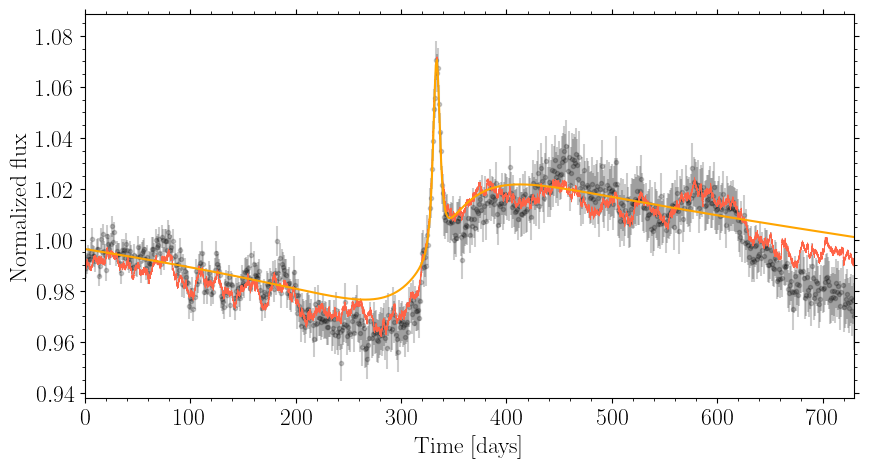

In [79]:
# Load Hu+2020 binned light curve of Spikey 
df = pd.read_feather(ddir / 'lc_spikey_fiducial_1h.ftr')
Q0=9

# Bin to 1-hour light curve 
df = ut.bin_lc(df, bin_size=1)
time = df.time.to_numpy()

# Generate relativistic Spikey model
params = smbhb.model_params()
params.t0    = 0.712
params.sigma = 0 
params.seed  = params.seed
model = smbhb.model(params)
dm = model.light_curve(time, df=True)

# Load variable template
sdir = path / '../workdir/smbhb/simulations/lcs/'
dv = pd.read_csv(sdir / 'varsource' / 'varsource_spikey_fiducial.txt', 
                 sep=' ', names=['time', 'dmag'])
dv.time /= 86400
dv['flux'] = ut.mag2flux(dv.dmag)

# Cut light curve to 2-year duration
tdur = 2 * ut.year2sec() / ut.day2sec()
df = df[df.time < 2*tdur]

t0 = df.time.iloc[0]
df.time -= t0
dv.time -= t0
dm.time -= t0
df.flux -= 0.008
time = df.time.to_numpy()
flux = df.flux.to_numpy()

# Plot light curve
fig, ax = pt.plot_lc(df, dv, cm=cv, lw=0.5)
ax.plot(dm.time, dm.flux, '-', c=cm);
# ax.set_xlim(300, 360)
# ax.set_ylim(0.950, 1.08);

---
### 1.1. Model Q
```
INFO:jaxns:Number of Markov-chains set to: 2000
Running over 6 devices.
--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 7595490
samples: 31062
phantom samples: 0
likelihood evals / sample: 244.5
phantom fraction (%): 0.0%
--------
logZ=2630.282 +- 0.062
max(logL)=2636.926
H=-5.31
ESS=2977
--------
mean: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
mean: 1.0 +- 0.014 | 0.983 / 1.001 / 1.016 | 1.001 | 1.001
--------
sigma: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
sigma: 0.0228 +- 0.0058 | 0.0165 / 0.0218 / 0.0305 | 0.0191 | 0.0191
--------
tau: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
tau: 180.0 +- 100.0 | 90.0 / 160.0 / 310.0 | 120.0 | 120.0
--------
CPU times: user 1h 12min 24s, sys: 4min 10s, total: 1h 16min 34s
Wall time: 28min 8s
```

In [80]:
filename = rdir / 'spikey_plato_jaxns_2yr24h_Q.npy'
priors = {
    'tau'  : dist.LogNormal(jnp.log(100.0), 1.0),
    'sigma': dist.LogNormal(jnp.log(jnp.std(flux)), 0.5),
    'mean' : dist.Normal(jnp.mean(flux), 0.5),
}

In [ ]:
%%time
result = bs.run_jaxns(
    df, params, priors, 
    build_mean=None, 
    build_kernel=bs.drw_kernel, 
    ofile=filename
)

INFO:jaxns:Number of Markov-chains set to: 2000


Running over 6 devices.


In [ ]:
result = ut.load_result(filename)

In [ ]:
# Show results
dm = bs.model_lightcurve_drw(time, result)
fig, ax = pt.plot_result(df, dm, Q0=Q0)
fig = pt.plot_corner(result, best_params='mle', true_params=True);

In [ ]:
# Print percentiles for latex
ut.get_percentiles(result, latex=True);

---
### 1.2. Model DM
```
INFO:jaxns:Number of Markov-chains set to: 2000
Running over 6 devices.
--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 63406136
samples: 76152
phantom samples: 0
likelihood evals / sample: 832.6
phantom fraction (%): 0.0%
--------
logZ=2550.94 +- 0.15
max(logL)=2588.27
H=-33.31
ESS=5088
--------
L: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
L: 0.89 +- 0.23 | 0.94 / 0.95 / 0.95 | 0.95 | 0.95
--------
P: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
P: 0.873 +- 0.0082 | 0.8626 / 0.8729 / 0.8832 | 0.8729 | 0.8729
--------
alpha: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
alpha: -1.04 +- 0.3 | -1.36 / -1.06 / -0.65 | -1.05 | -1.05
--------
e: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
e: 0.455 +- 0.017 | 0.433 / 0.455 / 0.476 | 0.457 | 0.457
--------
i: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
i: 83.15 +- 0.6 | 82.35 / 83.21 / 83.85 | 83.26 | 83.26
--------
logM1: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
logM1: 5.96 +- 0.98 | 5.16 / 5.78 / 6.45 | 5.07 | 5.07
--------
logM2: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
logM2: 9.09 +- 0.77 | 9.02 / 9.28 / 9.47 | 9.31 | 9.31
--------
t0: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
t0: 1.48 +- 0.63 | 1.18 / 1.2 / 2.87 | 1.2 | 1.2
--------
w: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
w: 231.0 +- 45.0 | 241.0 / 243.0 / 245.0 | 243.0 | 243.0
--------
CPU times: user 7h 50min 16s, sys: 3min 46s, total: 7h 54min 2s
Wall time: 1h 25min 24s
```

In [ ]:
filename = rdir / 'spikey_plato_jaxns_2yr24h_DM.npy'
priors = {
    'z'    : params.z,
    't0'   : dist.Uniform(0, 3),
    'P'    : dist.Uniform(0, 5),
    'i'    : dist.Uniform(0, 90),
    'e'    : dist.Uniform(0, 1),
    'w'    : dist.Uniform(0, 360),
    'logM1': dist.Uniform(5, 11),
    'logM2': dist.Uniform(5, 11),
    'alpha': dist.Uniform(-4, 4),
    'L'    : dist.Uniform(0, 1),
    'vz'   : params.vz,
}

In [ ]:
%%time
result = bs.run_jaxns(
    df, params, priors, 
    build_mean=bs.smbhb_mean_builder,
    build_kernel=None, 
    ofile=filename
)

In [ ]:
result = ut.load_result(filename)

In [ ]:
dm = smbhb.model_lightcurve(time, result['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm, Q0=Q0)
fig = pt.plot_corner(result, best_params='mle', true_params=True);

In [ ]:
# Resolve bimodality in t0
clusters_t = bs.get_posterior_clusters(df, result, param_cluster='t0', n_components=2)
result_t0 = clusters_t[0]
result_t1 = clusters_t[1]
fig = pt.plot_corner(result_t0, best_params='mle', true_params=True, color=c0);
fig = pt.plot_corner(result_t1, best_params='mle', true_params=True, color=c1);

In [ ]:
# Resolve bimodality in w
clusters_w = bs.get_posterior_clusters(df, result_t0, param_cluster='w', n_components=2)
result_w0 = clusters_w[0]
result_w1 = clusters_w[1]
fig = pt.plot_corner(result_w0, best_params='mle', true_params=True, color=c0);
fig = pt.plot_corner(result_w1, best_params='mle', true_params=True, color=c1);

In [ ]:
# Print percentiles for latex
ut.get_percentiles(result_w0, latex=True);

---
### 1.3. Model QDM
```
INFO:jaxns:Number of Markov-chains set to: 2000
Running over 6 devices.
--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 58049312
samples: 67134
phantom samples: 0
likelihood evals / sample: 864.7
phantom fraction (%): 0.0%
--------
logZ=2699.09 +- 0.13
max(logL)=2730.33
H=-22.85
ESS=6788
--------
L: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
L: 0.44 +- 0.27 | 0.1 / 0.46 / 0.8 | 0.11 | 0.11
--------
P: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
P: 1.15 +- 0.81 | 0.71 / 0.88 / 2.24 | 0.76 | 0.76
--------
alpha: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
alpha: 1.69 +- 0.94 | 0.64 / 1.96 / 2.38 | 1.1 | 1.1
--------
e: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
e: 0.49 +- 0.14 | 0.33 / 0.47 / 0.69 | 0.34 | 0.34
--------
i: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
i: 79.8 +- 3.2 | 76.7 / 80.2 / 82.8 | 81.6 | 81.6
--------
logM1: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
logM1: 6.7 +- 1.0 | 5.3 / 6.6 / 8.0 | 8.1 | 8.1
--------
logM2: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
logM2: 7.69 +- 0.78 | 6.45 / 7.81 / 8.47 | 7.76 | 7.76
--------
sigma: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
sigma: 0.0138 +- 0.0082 | 0.0071 / 0.011 / 0.0297 | 0.0065 | 0.0065
--------
t0: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
t0: 2.51 +- 0.92 | 0.28 / 2.88 / 2.92 | 2.91 | 2.91
--------
tau: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
tau: 370.0 +- 540.0 | 70.0 / 160.0 / 1220.0 | 90.0 | 90.0
--------
w: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
w: 217.0 +- 78.0 | 65.0 / 252.0 / 273.0 | 266.0 | 266.0
--------
CPU times: user 11h 14min 17s, sys: 39min 29s, total: 11h 53min 47s
Wall time: 3h 28min 35s
```

In [ ]:
filename = rdir / 'spikey_plato_jaxns_2yr24h_QDM.npy'
priors = {
    'z'    : params.z,
    'vz'   : params.vz,
    't0'   : dist.Uniform(0, 3),
    'P'    : dist.Uniform(0, 5),
    'i'    : dist.Uniform(0, 90),
    'e'    : dist.Uniform(0, 1),
    'w'    : dist.Uniform(0, 360),
    'logM1': dist.Uniform(5, 11),
    'logM2': dist.Uniform(5, 11),
    'alpha': dist.Uniform(-4, 4),
    'L'    : dist.Uniform(0, 1),
    'tau'  : dist.LogNormal(jnp.log(100.0), 1.0),
    'sigma': dist.LogNormal(jnp.log(jnp.std(flux)), 0.5),
}

In [ ]:
%%time 
result = bs.run_jaxns(
    df, params, priors, 
    build_mean=bs.smbhb_mean_builder, 
    build_kernel=bs.drw_kernel, 
    ofile=filename
)

In [ ]:
result = ut.load_result(filename)

In [ ]:
# Show results of QDM and DM model
dm_QDM = bs.model_lightcurve_drw(time, result)
dm_DM = smbhb.model_lightcurve(time, result['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm_QDM, Q0=Q0)
ax[0].plot(dm_DM.time, dm_DM.flux, c=c0, lw=2)
fig = pt.plot_corner(result, best_params='mle', true_params=True);

In [ ]:
# Resolve bimodality in t0
clusters_t = bs.get_posterior_clusters(df, result, param_cluster='t0', n_components=2)
result_t0 = clusters_t[0]
result_t1 = clusters_t[1]
fig = pt.plot_corner(result_t0, best_params='mle', true_params=True, color=c0);
fig = pt.plot_corner(result_t1, best_params='mle', true_params=True, color=c1);

In [ ]:
# Resolve bimodality in w
clusters_w = bs.get_posterior_clusters(df, result_t0, param_cluster='w', n_components=2)
result_w0 = clusters_w[0]
result_w1 = clusters_w[1]
fig = pt.plot_corner(result_w0, best_params='mle', true_params=True, color=c0);
fig = pt.plot_corner(result_w1, best_params='mle', true_params=True, color=c1);

In [ ]:
# Print percentiles for latex
ut.get_percentiles(result_w1, latex=True);

---
## 2. *Plato* 4-yr light curve
---

In [ ]:
# Load Hu+2020 binned light curve of Spikey 
df = pd.read_feather(ddir / 'lc_spikey_fiducial_1h.ftr')

# Bin to 1-hour light curve 
df = ut.bin_lc(df, bin_size=1)
time = df.time.to_numpy()

# Generate relativistic Spikey model
params = smbhb.model_params()
params.t0    = 0.712
params.sigma = 0 
params.seed  = params.seed
model = smbhb.model(params)
dm = model.light_curve(time, df=True)

# Load variable template
sdir = path / '../workdir/smbhb/simulations/lcs/'
dv = pd.read_csv(sdir / 'varsource' / 'varsource_spikey_fiducial.txt', 
                 sep=' ', names=['time', 'dmag'])
dv.time /= 86400
dv['flux'] = ut.mag2flux(dv.dmag)

t0 = df.time.iloc[0]
df.time -= t0
dv.time -= t0
dm.time -= t0
df.flux -= 0.008
time = df.time.to_numpy()
flux = df.flux.to_numpy()

# Plot light curve
fig, ax = pt.plot_lc(df, dv, cm=cv, lw=0.5)
ax.plot(dm.time, dm.flux, '-', c=cm);
# ax.set_xlim(270, 370)
# ax.set_ylim(0.950, 1.08)
# ax.set_xlim(1100, 1200)
# ax.set_ylim(0.950, 1.083)

---
### 2.1. Model Q
```
INFO:jaxns:Number of Markov-chains set to: 2000
Running over 6 devices.
--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 8258054
samples: 32064
phantom samples: 0
likelihood evals / sample: 257.5
phantom fraction (%): 0.0%
--------
logZ=4860.362 +- 0.066
max(logL)=4867.735
H=-5.9
ESS=3202
--------
mean: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
mean: 0.9997 +- 0.0093 | 0.9891 / 0.9995 / 1.0098 | 0.9996 | 0.9996
--------
sigma: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
sigma: 0.0197 +- 0.0048 | 0.015 / 0.0187 / 0.0256 | 0.0166 | 0.0166
--------
tau: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
tau: 166.0 +- 99.0 | 88.0 / 140.0 / 270.0 | 110.0 | 110.0
--------
CPU times: user 3h 44min 41s, sys: 5min 22s, total: 3h 50min 3s
Wall time: 55min 52s
```

In [ ]:
filename = rdir / 'spikey_plato_jaxns_4yr24h_Q.npy'
priors = {
    'tau'  : dist.LogNormal(jnp.log(100.0), 1.0),
    'sigma': dist.LogNormal(jnp.log(jnp.std(flux)), 0.5),
    'mean' : dist.Normal(jnp.mean(flux), 0.5),
}

In [ ]:
%%time
result = bs.run_jaxns(
    df, params, priors, 
    build_mean=None, 
    build_kernel=bs.drw_kernel, 
    ofile=filename
)

In [ ]:
result = ut.load_result(filename)

In [ ]:
# Show results
dm = bs.model_lightcurve_drw(time, result)
fig, ax = pt.plot_result(df, dm, cm=c1, alpha=0.2)
fig = pt.plot_corner(result, best_params='mle', true_params=True, color=c1);

In [ ]:
# Print percentiles for latex
ut.get_percentiles(result, latex=True);

---
### 2.2. Model DM

In [ ]:
filename = rdir / 'spikey_plato_jaxns_4yr24h_DM.npy'
priors = {
    'z'    : params.z,
    't0'   : dist.Uniform(0, 3),
    'P'    : dist.Uniform(0, 5),
    'i'    : dist.Uniform(0, 90),
    'e'    : dist.Uniform(0, 1),
    'w'    : dist.Uniform(0, 360),
    'logM1': dist.Uniform(5, 11),
    'logM2': dist.Uniform(5, 11),
    'alpha': dist.Uniform(-4, 4),
    'L'    : dist.Uniform(0, 1),
    'vz'   : params.vz,
}

In [ ]:
%%time
result = bs.run_jaxns(
    df, params, priors, 
    build_mean=bs.smbhb_mean_builder,
    build_kernel=None, 
    ofile=filename
)
# result = ut.load_result(filename)

In [ ]:
# Show results
dm = smbhb.model_lightcurve(time, result['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm, cm=c2, Q0=12, alpha=0.3)
fig = pt.plot_corner(result, best_params='mle', true_params=True, color=c2);

In [ ]:
# Print percentiles for latex
ut.get_percentiles(result, latex=True);

---
### 2.3. Model QDM 

In [ ]:
# Print percentiles for latex
ut.get_percentiles(result, latex=True);